# PRIMO - The Plugging & Abandonment (P&A) Project Optimizer - Workflow Demonstration

This notebook demonstrates the capabilities of PRIMO - The P&A Project Optimizer. We follow the workflow in the image below. PRIMO reads input data on marginal wells and their characteristics, and analyzes it with respect to **USER-DEFINED PRIORITIES AND PREFERENCES** to provide recommendations on the design of impactful and efficient P&A projects. 

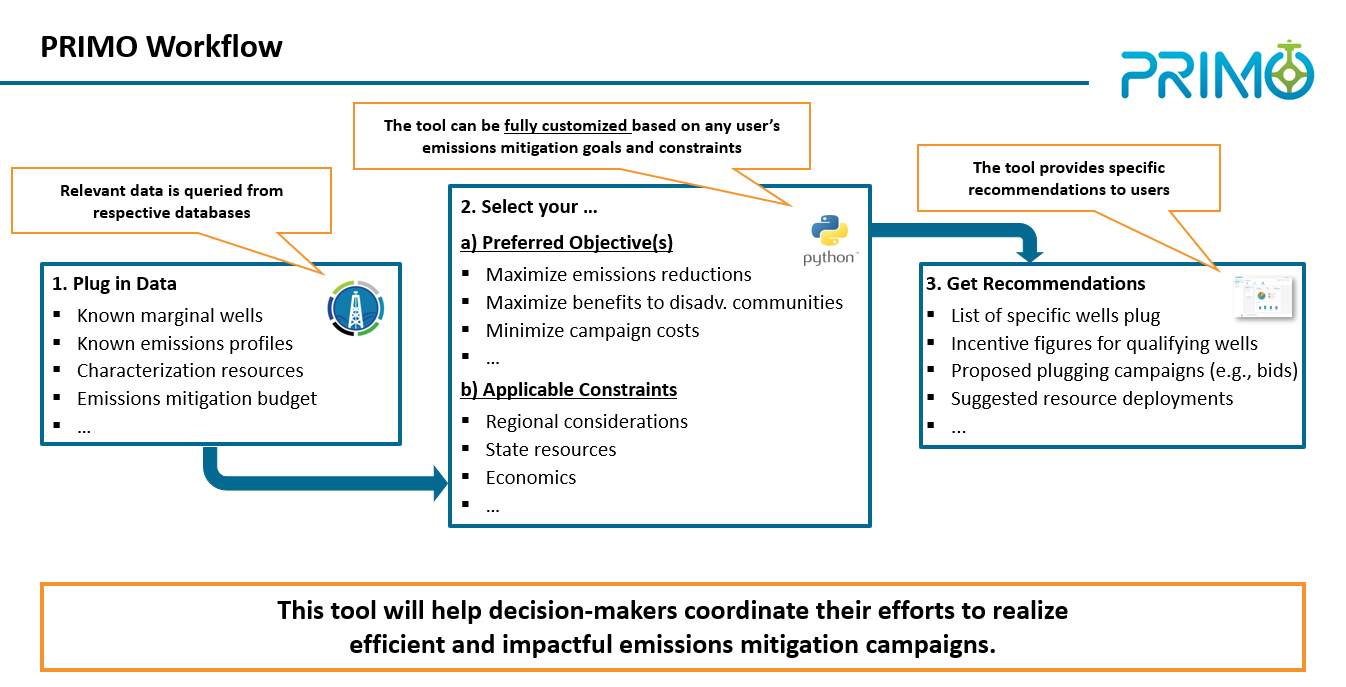

#### **Notice**

This demonstration uses randomized data on a 2-d grid (x and y coordinates), where the x-coordinate represents the latitude, and the y-coordinate represents the longitude of a well. The results are accordingly visualized on scatter plots. For real-life data, PRIMO is designed to process geospatial data containing latitude and longitude information such as shapefiles. As a result, PRIMO has advanced visualization capabilities that uses detailed maps instead of 2-d grids. In addition, PRIMO also has utilities to query data on disadvantaged communities, population density, etc. from external sources, such as U.S. Census.

Overall, this notebook is primarily meant to showcase the workflow and functionality of PRIMO. PRIMO is under active development: please reach out to primo@netl.doe.gov for questions, comments, feedback or feature requests.

#### **Import PRIMO Module**

Please follow the download/installation instructions described here (https://primo.readthedocs.io/en/latest/install.html). Note that basic python programming experience/expertise is required to understand this demonstration.

We begin by importing the PRIMO module to use its capabilities. The `demo.visualization` module contains functions for plotting well data on a scatter plot. These functions are written specifically for this demonstration, so they are not available in the `primo` module. Instead, `primo` module has a more advanced functionality called `VisualizeData` for plotting real-life data on detailed maps. Please refer to the documentation for more details on the functionality.

In [1]:
# Imports from installed libraries
from IPython.display import display, Markdown

# Import PRIMO module
import primo
import primo.demo.visualization as visualization


# The following command generates nicely formatted 
# information/warnings/errors while running PRIMO functionalities
primo.setup_logger()

## **Capability 1: Prioritizing/Rank-listing Marginal Conventional Wells**
The first step in the workflow, and one of the primary capabilities of PRIMO, is to ranklist/prioritize wells based on user-defined priorities. Typically, the number of marginal wells under consideration is significantly larger than what can be plugged with the budget available. Hence, we rank the candidate pool of wells based on user-defined priorities to quickly identify attractive wells for plugging. 

**NOTE:** Selecting the top most wells need not correspond to the optimal plugging, since it does not take into account several important factors such as the distance between wells, economies of scale, distribution of wells into projects, etc. Nevertheless, this step generates the data required for rigorously determining the optimal plugging campaign.

The main inputs for this capability are 
1. *Choice of impact metrics and their associated weights*
2. *Choice of efficiency metrics and their associated weights*
2. *Required data to assess the impact and efficiency for all the marginal conventional wells* under consideration.

#### **Impact Metric Selection**

Currently, PRIMO supports the following list of impact metrics. PRIMO also allows users to define new/custom metrics, and add as many new new metrics as desired for rank-listing. Note that the sum of weights of all the impact metrics must add up to 100.

Next, Some of the impact metrics have submetrics. For example, the metric `sensitive_receptors` is further divided into `hospitals`, `schools`, `buildings`, etc. The weights associated with all the submetrics must add up to 100.

In [2]:
# Define impact metrics by creating an instance of ImpactMetrics class
im_metrics = primo.ImpactMetrics()

print(im_metrics)

                                                      Metric Name  Metric weight
well_history                                         Well History              0
ecological_receptors                         Ecological Receptors              0
environment                                           Environment              0
other_losses                                         Other Losses              0
cost_of_plugging                           Cost of Plugging [USD]              0
high_pressure_observed            High Pressure Observed [Yes/No]              0
idle_status_duration                 Idle Status Duration [Years]              0
in_tribal_land                            In Tribal Land [Yes/No]              0
likely_to_be_orphaned              Likely to be Orphaned [Yes/No]              0
mechanical_integrity_test           Mechanical Integrity Test [#]              0
number_of_mcws_nearby                   Number of MCWs Nearby [#]              0
otherwise_incentivized_well 

In [3]:
# (OPTIONAL) Metrics/submetrics that are not required can be deleted.
# This is an optional step. As long as their weight is set to zero, metric/submetrics
# that are not needed can still remain in the im_metrics object.
im_metrics.delete_metric("other_losses")
im_metrics.delete_metric("five_year_production_volume")
im_metrics.delete_metric("well_integrity")
im_metrics.delete_metric("environment")

# Submetrics can also be deleted in a similar manner
im_metrics.delete_submetric("buildings_near")
im_metrics.delete_submetric("buildings_far")

In [4]:
# Specify weights for all the impact metrics.
# NOTE: This method will throw an error if the weights do not add up to 100
im_metrics.set_weight(
    primary_metrics={
        "well_history": 35,
        "sensitive_receptors": 20,
        "ann_production_volume": 20,
        "well_age": 15,
        "well_count": 10,
    },
    submetrics={
        "well_history": {
            "leak": 40,
            "compliance": 30,
            "violation": 20,
            "incident": 10,
        },
        "sensitive_receptors": {
            "schools": 50,
            "hospitals": 50,
        },
        "ann_production_volume": {
            "ann_gas_production": 50,
            "ann_oil_production": 50,
        }
    },
)

print(im_metrics)

                                                      Metric Name  Metric weight
well_history                                         Well History             35
ecological_receptors                         Ecological Receptors              0
cost_of_plugging                           Cost of Plugging [USD]              0
high_pressure_observed            High Pressure Observed [Yes/No]              0
idle_status_duration                 Idle Status Duration [Years]              0
in_tribal_land                            In Tribal Land [Yes/No]              0
likely_to_be_orphaned              Likely to be Orphaned [Yes/No]              0
mechanical_integrity_test           Mechanical Integrity Test [#]              0
number_of_mcws_nearby                   Number of MCWs Nearby [#]              0
otherwise_incentivized_well  Otherwise Incentivized Well [Yes/No]              0
well_age                                                 Well Age             15
well_count                  

For convenience and ease of use, PRIMO also provides widgets to set weights using sliders. Uncomment the cells below to use the widget. Please follow the guidelines below when selecting your priorities and their respective weights:
- Use the checkboxes to select preferred priorities and the respective sliders to specify the weight.
- Some priorities may also allow for the specification of sub-priorities. Use the checkbox to select a sub-priority and the corresponding slider to specify the weight of the sub-priority
- A sub-priority can only be selected if the corresponding "parent" priority has been selected
- The sum of all priorities needs to be 100
- The sum of all sub-priorities within each priority needs to be 100
- If you wish to change the weights after confirming them or getting an error, please re-run the cell in order to get a fresh start

In [5]:
# # Alternatively, use the widget to set weights
# im_metrics_widget = im_metrics.build_widget()
# im_metrics_widget.display()

In [6]:
# # Update weights from the widget
# im_metrics.set_weight_from_widget(im_metrics_widget)

#### **Efficiency Metric Selection**

Ideal P&A projects not only include (many) high-priority wells but also prioritize the efficient use of available resources (e.g., budget, crews, equipment, ...). PRIMO has been designed to quantify the expected IMPACT and EFFICIENCY of recommended P&A candidate projects.

We employ a series of user-defined functions to calculate essential KPIs for each proposed P&A project.

- **Number of Wells**: The more wells a P&A project includes, the the more efficient plugging operations are expected to be - especially if the respective wells are close to each other. Note that upper limits on the number of wells per project may be imposed. Counted as the total number of wells associated with each project.

- **Well Proximities**: This KPI quantifies the "compactness" of any given P&A project. Wells close to each other lead to efficient plugging projects (e.g., reduced mobilization costs/efforts). Defined as the average absolute distance from well locations to the centroid of the project cluster.

- **Well Accessibility - Road Access**: The distance of any well to the closest road access point is used as a measure of well accessibility. The further a well is from any established road, the most costly it is presumed the P&A operation will be. Road construction cost can be significant contributor to project costs and efforts. Measured as the average absolute distance from well locations to their nearest road point. 

- **Well Accessibility - Elevation Change**: This KPI attempts to assess the accessibility of wells by comparing the elevation of the closest road access points to the elevation of the wells contained in a P&A project. If multiple wells in a project are characterized by significant elevation changes, they are presumed to be less accessible which increases P&A costs leading to inefficiencies. Computed as the average absolute elevation delta across all wells within the project group. The elevation delta is referred as the difference in surface elevation of the well and the elevation of the closest road access point. 

- **Well Characteristics - Age Range**: Wells with similar characteristics make for efficient P&A projects. As such, significant differences in well ages within a P&A project can pose challenges to P&A operations. The closer wells are in terms of age, the more efficient a P&A project is presumed to be. This metric Determined by subtracting the minimum age from the maximum age of wells within each P&A project. 

- **Well Characteristics - Depth Range**: Significant differences in well depths within a P&A project can pose challenges to P&A operations. The closer the wells are in terms of depth, the more efficient a P&A project is presumed to be. Calculated as the difference between the maximum and minimum depths of wells within the cluster. 

- **Number of Unique Well Owners**: As the number of (unique) well owners included in a given P&A project increases, so does the effort to manage a given project. Captured by counting the number of distinct company names associated with wells within each project. 

In [7]:
# Efficiency metrics can be set in a similar manner
eff_metrics = primo.EfficiencyMetrics()

# Set weights for the metrics
# NOTE: This method throws an error if the weights do not add up to 100.
eff_metrics.set_weight(
    primary_metrics={
        "num_wells": 20,
        "num_unique_owners": 30,
        "elevation_delta": 20,
        "age_range": 10,
        "depth_range": 20,
    }
)

# Print the updated metrics
print(eff_metrics)

                                          Metric Name  Metric weight
num_wells                             Number of Wells             20
num_unique_owners             Number of Unique Owners             30
elevation_delta                   Elevation Delta [m]             20
age_range                           Age Range [Years]             10
depth_range                          Depth Range [ft]             20
dist_range                     Distance Range [miles]              0
record_completeness               Record Completeness              0
dist_to_road                 Distance to Road [miles]              0
population_density   Total Population Density [#/km2]              0
                                                Total            100


Similar to impact metrics, PRIMO provides a widget to specify the weights associated with the efficiency metrics. Uncomment the cells below to specify the weights using the widget.

In [8]:
# # Set weights using the widget
# eff_metrics_widget = eff_metrics.build_widget()
# eff_metrics_widget.display()

In [9]:
# # Update weights from the widget
# eff_metrics.set_weight_from_widget(eff_metrics_widget)

## Read Well Data

In [10]:
# Construct an object to store column names
col_names = primo.WellDataColumnNames(
    well_id="API Well Number",
    latitude="y",
    longitude="x",
    operator_name="Operator Name",
    age="Age [Years]",
    depth="Depth [ft]",

    leak="Leak [Yes/No]",
    compliance="Compliance [Yes/No]",
    violation="Violation [Yes/No]",
    incident="Incident [Yes/No]",

    hospitals="Number of Nearby Hospitals",
    schools="Number of Nearby Schools",

    ann_gas_production="Gas [Mcf/Year]",
    ann_oil_production="Oil [bbl/Year]",
    
    # These are columns used in the efficiency calculation
    elevation_delta="Elevation Delta [m]",
    dist_to_road="Distance to Road [miles]",
)

# Create the well data object
wd = primo.WellData(
    data="Example_1_data.csv",
    column_names=col_names,
    impact_metrics=im_metrics,
    efficiency_metrics=eff_metrics,
)

primo: INFO: Reading the well data from the input file.
primo: INFO: Finished reading the well data.
primo: INFO: Beginning to perform preliminary data checks.
primo: INFO: Checking availability and uniqueness of well ids.
primo: INFO: Checking if latitude and longitude information is available for all wells.
primo: INFO: Checking if the operator name is available for all wells.
primo: INFO: Checking if age is available for all wells.
primo: INFO: Checking if depth is available for all wells.
primo: INFO: Checking if ann_gas_production is available for all wells.
primo: INFO: Checking if ann_oil_production is available for all wells.
primo: INFO: Completed processing the essential inputs.
primo: INFO: Finished preliminary processing.
primo: WARNING: Converting negative elevation delta values to positive.


#### Visualization of Marginal Conventional Wells (MCW) Population

PRIMO can distinguish gas and oil wells, and handle them separately for prioritization and plugging. The user can specify the type of well (`"Gas"` or `"Oil"`) in the input data. Alternatively, the user can provide the annual gas production rate [in Mcf/yr] and the annual oil production rate [in bbl/yr]. Based on their barrels of oil equivalent (BOE) value, PRIMO will categorize each well as either `"Gas"` or `"Oil"`. 

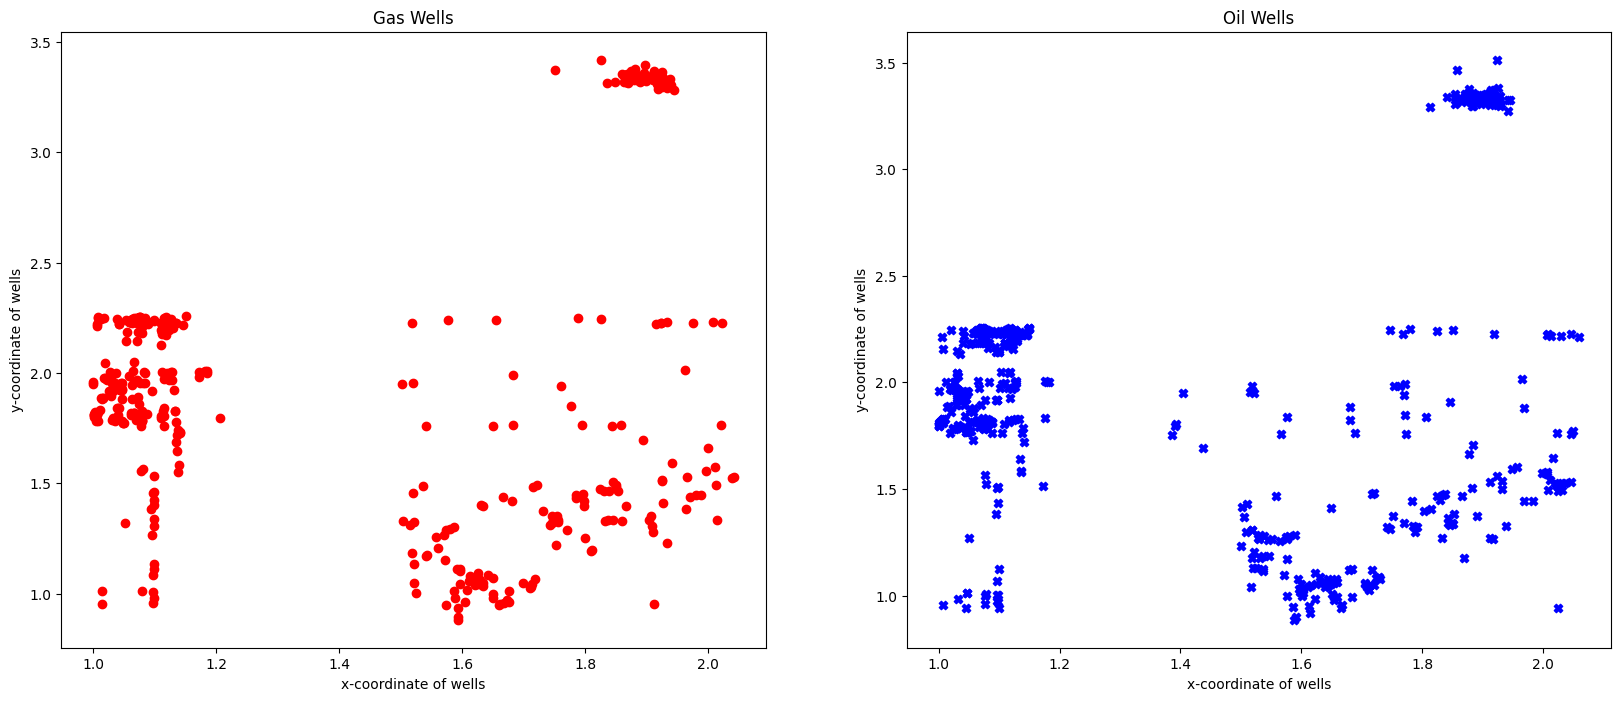

In [11]:
# The property `get_gas_oil_wells` partitions the data set as gas wells
# and oil wells based on their annual BOE production value.
gas_oil_wells = wd.get_gas_oil_wells

gas_wells = gas_oil_wells["gas"]   # WellData object
oil_wells = gas_oil_wells["oil"]   # WellData object

# Visualize wells on an x-y plot.
# NOTE: For real-life data, use `primo.VisualizeData`, with the 
# necessary shapefiles as input, for visualization on detailed maps.
visualization.visualize_gas_oil_wells(gas_wells, oil_wells)

#### Compute priority scores and Display High-priority Wells

In [12]:
# Compute priority scores of gas wells
gas_wells.compute_priority_scores()

primo: INFO: Computing scores for metric/submetric compliance/Compliance [Yes/No].
primo: INFO: Computing scores for metric/submetric incident/Incident [Yes/No].
primo: INFO: Computing scores for metric/submetric leak/Hydrocarbon Leak [Yes/No].
primo: INFO: Computing scores for metric/submetric violation/Violation [Yes/No].
primo: INFO: Computing scores for metric/submetric well_age/Well Age.
primo: INFO: Computing scores for metric/submetric well_count/Owner Well Count.
primo: INFO: Computing scores for metric/submetric ann_gas_production/Annual Gas Production [in Mcf/Year].
primo: INFO: Computing scores for metric/submetric ann_oil_production/Annual Oil Production [in bbl/Year].
primo: INFO: Computing scores for metric/submetric hospitals/Hospitals.
primo: INFO: Computing scores for metric/submetric schools/Schools.
primo: INFO: Computing the total priority score.
primo: INFO: Completed the calculation of priority scores.


In [13]:
# Display top 10 gas wells based on the priority score
gas_wells.get_high_priority_wells(num_wells=10)

Well Rank,API Well Number,Operator Name,y,x,Age [Years],Depth [ft],Priority Score [0-100],Compliance [Yes/No] Score [0-10.5],Incident [Yes/No] Score [0-3.5],Leak [Yes/No] Score [0-14.0],Violation [Yes/No] Score [0-7.0],Age [Years] Score [0-15],Owner Well-Count Score [0-10],Gas [Mcf/Year] Score [0-10.0],Oil [bbl/Year] Score [0-10.0],Number of Nearby Hospitals Score [0-10.0],Number of Nearby Schools Score [0-10.0],Priority Score [0-100]
1,49439,Owner 19,3.32,1.89,126,1781,80.28,10.5,3.5,0.0,7.0,12.58,10.00,9.47,9.23,10.00,8.0,80.28
2,58584,Owner 236,3.34,1.89,121,12639,73.89,10.5,3.5,0.0,0.0,12.08,10.00,9.81,10.00,10.00,8.0,73.89
3,21486,Owner 58,3.35,1.88,124,10416,72.85,10.5,3.5,0.0,0.0,12.38,9.05,9.58,9.84,10.00,8.0,72.85
4,26239,Owner 111,3.35,1.88,106,12852,71.46,10.5,3.5,0.0,0.0,10.57,9.05,9.84,10.00,10.00,8.0,71.46
5,73984,Owner 142,3.31,1.84,122,3796,71.01,10.5,3.5,0.0,0.0,12.18,8.19,9.12,9.52,10.00,8.0,71.01
6,35551,Owner 151,3.37,1.91,145,6845,70.71,10.5,0.0,0.0,0.0,14.50,9.05,8.94,9.73,10.00,8.0,70.71
7,84290,Owner 2,3.33,1.94,84,2261,70.03,10.5,3.5,14.0,0.0,8.36,9.05,0.04,6.59,10.00,8.0,70.03
8,21580,Owner 224,1.33,1.86,135,5192,69.85,10.5,3.5,0.0,7.0,13.49,7.41,9.95,10.00,0.00,8.0,69.85
9,97876,Owner 183,3.33,1.90,111,10459,69.67,10.5,3.5,0.0,0.0,11.07,10.00,6.60,10.00,10.00,8.0,69.67
10,50038,Owner 117,1.83,1.08,83,5892,69.64,10.5,3.5,0.0,7.0,8.26,9.05,10.00,10.00,3.33,8.0,69.64


In [14]:
# Compute priority scores of oil wells
oil_wells.compute_priority_scores()

primo: INFO: Computing scores for metric/submetric compliance/Compliance [Yes/No].
primo: INFO: Computing scores for metric/submetric incident/Incident [Yes/No].
primo: INFO: Computing scores for metric/submetric leak/Hydrocarbon Leak [Yes/No].
primo: INFO: Computing scores for metric/submetric violation/Violation [Yes/No].
primo: INFO: Computing scores for metric/submetric well_age/Well Age.
primo: INFO: Computing scores for metric/submetric well_count/Owner Well Count.
primo: INFO: Computing scores for metric/submetric ann_gas_production/Annual Gas Production [in Mcf/Year].
primo: INFO: Computing scores for metric/submetric ann_oil_production/Annual Oil Production [in bbl/Year].
primo: INFO: Computing scores for metric/submetric hospitals/Hospitals.
primo: INFO: Computing scores for metric/submetric schools/Schools.
primo: INFO: Computing the total priority score.
primo: INFO: Completed the calculation of priority scores.


In [15]:
# Display top 10 oil wells based on the priority score
oil_wells.get_high_priority_wells(num_wells=10)

Well Rank,API Well Number,Operator Name,y,x,Age [Years],Depth [ft],Priority Score [0-100],Compliance [Yes/No] Score [0-10.5],Incident [Yes/No] Score [0-3.5],Leak [Yes/No] Score [0-14.0],Violation [Yes/No] Score [0-7.0],Age [Years] Score [0-15],Owner Well-Count Score [0-10],Gas [Mcf/Year] Score [0-10.0],Oil [bbl/Year] Score [0-10.0],Number of Nearby Hospitals Score [0-10.0],Number of Nearby Schools Score [0-10.0],Priority Score [0-100]
1,21133,Owner 53,1.82,1.06,148,4199,75.01,10.5,3.5,0.0,7.0,14.80,8.19,10.00,9.96,2.5,8.57,75.01
2,27016,Owner 108,3.31,1.88,47,1191,74.79,10.5,0.0,14.0,0.0,4.63,10.00,10.00,9.59,7.5,8.57,74.79
3,22370,Owner 194,2.22,1.15,144,4565,74.37,10.5,3.5,0.0,7.0,14.40,8.19,9.77,9.95,2.5,8.57,74.37
4,44388,Owner 137,2.22,1.13,139,11323,73.37,10.5,3.5,0.0,7.0,13.89,7.41,10.00,10.00,2.5,8.57,73.37
5,55133,Owner 97,3.33,1.89,128,9581,72.80,10.5,3.5,0.0,0.0,12.79,10.00,9.99,9.95,7.5,8.57,72.80
6,83240,Owner 23,3.38,1.93,120,9066,71.87,10.5,3.5,0.0,7.0,11.98,9.05,9.93,3.85,7.5,8.57,71.87
7,85318,Owner 102,3.33,1.89,98,9605,71.67,10.5,3.5,0.0,0.0,9.77,10.00,10.00,9.34,10.0,8.57,71.67
8,67212,Owner 101,3.33,1.94,136,2536,70.01,10.5,0.0,0.0,0.0,13.59,10.00,9.90,9.95,7.5,8.57,70.01
9,38073,Owner 154,3.35,1.91,106,3429,69.98,10.5,3.5,0.0,0.0,10.57,10.00,9.64,9.70,7.5,8.57,69.98
10,27084,Owner 104,1.78,1.07,139,3898,68.79,10.5,3.5,0.0,0.0,13.89,10.00,10.00,9.83,2.5,8.57,68.79


## Capability 2: Budget-Specific P&A Projects Optimization 
To determine high-impact, high-efficiency P&A within the available budget, we use an optimization model. The optimization carefully evaluates all possible combinations of wells for plugging projects and helps us select the best campaigns in a data-based, transparent and defensible way.

The goal of the optimization is to seek those P&A projects that are not only impactful but will also lead to the most efficient use of P&A resources. The impact of a P&A project is determined by the priority scores of the wells contained within (as per the calculations outline above). More information on the definition and calculation of the predicted efficiency of a P&A project is provided below.

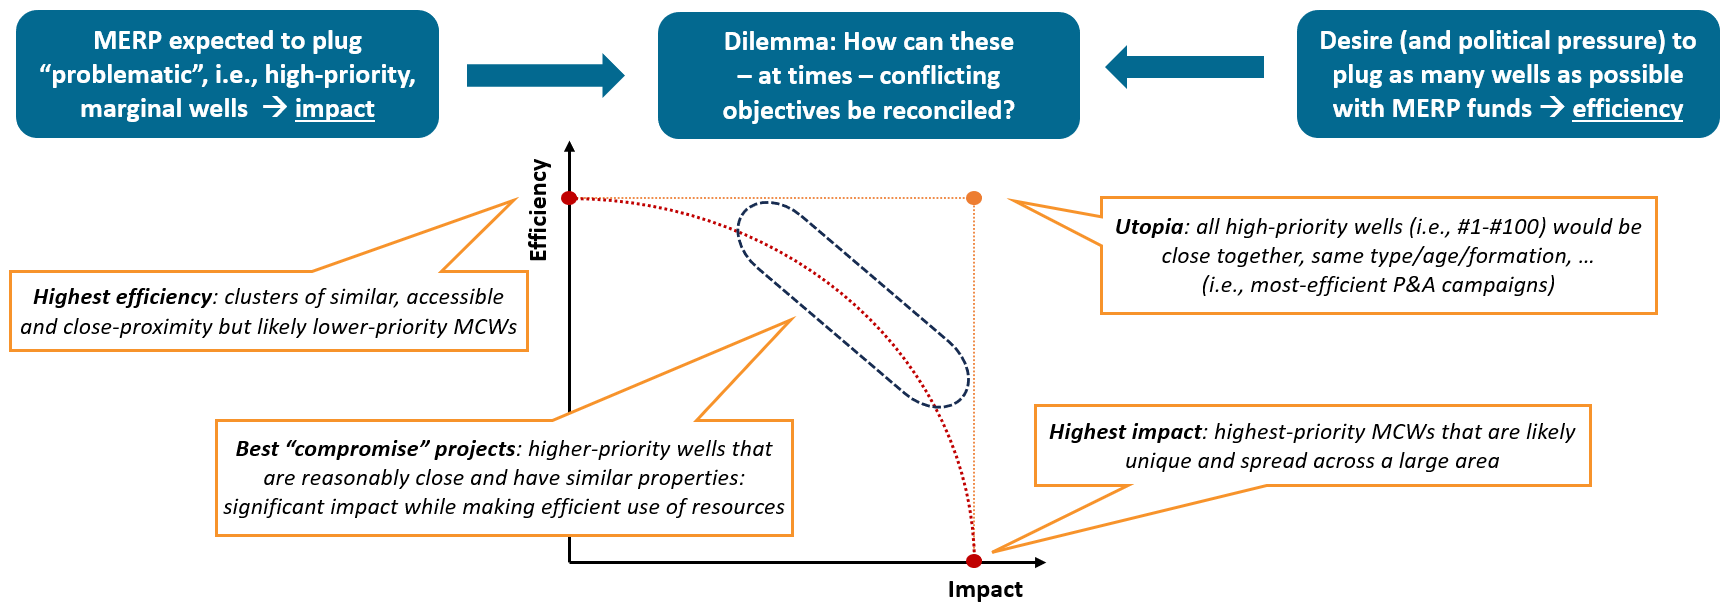

### State-Wide Program Constraints

In [16]:
max_wells_per_owner = 1  #
threshold_distance = 10  # [in miles]
gas_budget = 3.21e6      # USD
max_wells_in_project = None

# Mobilization cost
mobilization_cost = {1: 120000, 2: 210000, 3: 280000, 4: 350000}
for n_wells in range(5, len(gas_wells) + 1):
    mobilization_cost[n_wells] = n_wells * 84000

### Clustering Wells to Identify High-Impact, High-Efficiency P&A Candidate Projects
At present, wells are clustered based on proximity and similarity in characteristics (e.g. well age) so they can be organized into IMPACTFUL and EFFICIENT P&A projects. To identify groups of wells that would form a promising set for a project, we apply a constrained clustering algorithm.

### Optimizing for P&A Gas Projects 

primo: INFO: Processing optimization model inputs.
primo: INFO: Clustering Data in OptModelInputs
primo: INFO: Finished processing optimization model inputs.


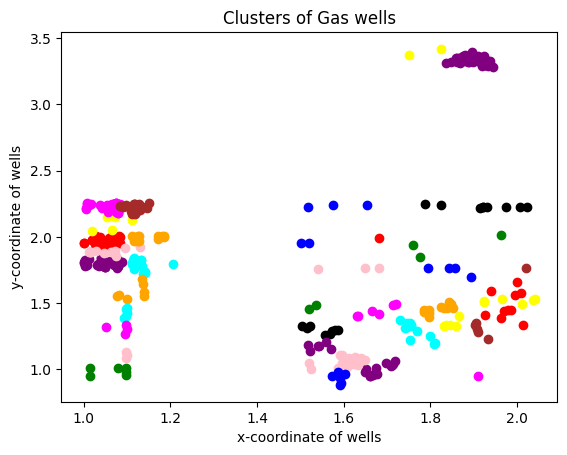

In [17]:
# Set inputs for the optimization models
gas_model_inputs = primo.OptModelInputs(
    well_data=gas_wells,
    total_budget=gas_budget,
    mobilization_cost=mobilization_cost,
    threshold_distance=threshold_distance,
    max_wells_per_owner=max_wells_per_owner,
    max_wells_in_project=max_wells_in_project,
    objective_weight_impact=100,
)

visualization.visualize_clusters(gas_wells, well_type="Gas")

In [18]:
model = gas_model_inputs.build_optimization_model()
opt_campaign_gas = gas_model_inputs.solve_model(solver="highs")

primo: INFO: Beginning to construct the optimization model.
primo: INFO: Completed the construction of the optimization model.
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
RUN!
MIP  has 378 rows; 1069 cols; 2435 nonzeros; 898 integer variables (898 binary)
Coefficient ranges:
  Matrix [1e-01, 5e+01]
  Cost   [2e+01, 8e+01]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 3e+00]
Presolving model
285 rows, 967 cols, 2243 nonzeros  0s
203 rows, 842 cols, 1951 nonzeros  0s
203 rows, 840 cols, 2569 nonzeros  0s

Solving MIP model with:
   203 rows
   840 cols (839 binary, 0 integer, 1 implied int., 0 continuous)
   2569 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic; L => Sub-MIP;
     P => Empty MIP; R => Randomized rounding; S => Solve LP; T => Evaluate node; U => Unbounded;
     z => Trivial zero; l => Trivial lower; u => Trivial upper; p => Trivial point; X => User solution

        Nodes      |    B&B Tr

### RESULT: Summary of PRIMO-Recommended High-Impact, High-Efficiency P&A Gas Projects

In [19]:
opt_campaign_gas

Project ID,Number of Wells,Plugging Cost [$],Impact Score [0-100],Efficiency Score [0-100]
1,22,"1,848,000",68.87,22.48
11,7,"588,000",65.61,20.78
13,4,"350,000",64.01,37.06
19,5,"420,000",64.80,18.48


In [20]:
project_sort = primo.ProjectComparison(
    projects=list(opt_campaign_gas.projects.values()),
    sorting_metric="total_impact_score",
)
project_sort.display()

In [21]:
opt_campaign_gas.display_efficiency_metric_scores()

Project ID,Num Wells Score [0-20],Num Unique Owners Score [0-30],Elevation Delta Score [0-20],Age Range Score [0-10],Depth Range Score [0-20],Efficiency Score [0-100],Accessibility Score [0-20]
1,17.60,0.00,0.40,4.43,0.05,22.48,0.40
11,5.60,0.00,0.08,5.97,9.13,20.78,0.08
13,3.20,7.50,16.40,5.57,4.39,37.06,16.40
19,4.00,0.00,0.56,1.21,12.71,18.48,0.56


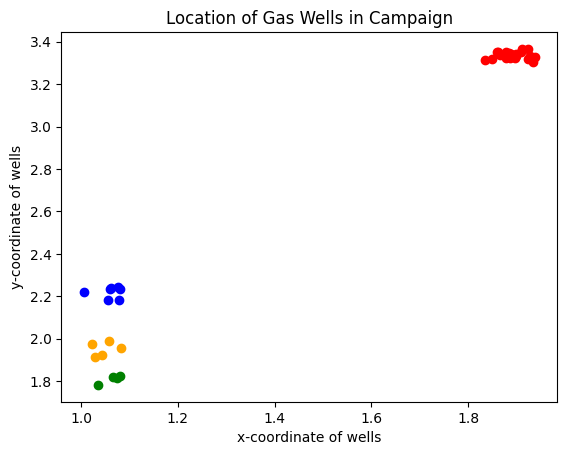

In [22]:
# NOTE: For real-life data use the methods in primo.VisualizeData 
opt_campaign_gas.plot_campaign(title="Location of Gas Wells in Campaign")

In [23]:
# View details of all wells in a specific project
opt_campaign_gas.projects[13]

Well Rank,API Well Number,Operator Name,y,x,Age [Years],Depth [ft],Priority Score [0-100],Compliance [Yes/No] Score [0-10.5],Incident [Yes/No] Score [0-3.5],Leak [Yes/No] Score [0-14.0],Violation [Yes/No] Score [0-7.0],Age [Years] Score [0-15],Owner Well-Count Score [0-10],Gas [Mcf/Year] Score [0-10.0],Oil [bbl/Year] Score [0-10.0],Number of Nearby Hospitals Score [0-10.0],Number of Nearby Schools Score [0-10.0],Priority Score [0-100]
10,50038,Owner 117,1.83,1.08,83,5892,69.64,10.5,3.5,0.0,7.0,8.26,9.05,10.00,10.00,3.33,8.0,69.64
56,16079,Owner 120,1.78,1.04,76,10119,62.84,10.5,3.5,0.0,0.0,7.55,10.00,9.95,10.00,3.33,8.0,62.84
58,46413,Owner 51,1.82,1.07,142,111,62.30,10.5,0.0,0.0,0.0,14.19,8.19,9.06,9.02,3.33,8.0,62.30
74,13528,Owner 107,1.82,1.07,142,7216,61.28,10.5,0.0,0.0,0.0,14.19,6.07,9.19,10.00,3.33,8.0,61.28


## Capability 3: Manual overrides for existing projects

PRIMO allows users to modify projects manually to satisfy requirements not considered above.

Please use the widgets to select the projects and/or wells:
- Step 1 - Remove Widget: This widget allows you to remove projects and/or wells from the recommended P&A projects.
    - Select P&A projects that should be removed from the recommendations. To confirm your selection, press the "Select Projects to Manually Remove" button. 
    - Select wells that should be removed from the recommended P&A projects. To confirm your selection, press the "Select Wells to Manually Remove" button. 
    - Once you are satisfied with your selections, please press the "Confirm Removal" button to proceed to the next step.
- Step 2 - Add Widget: Use this widget to select wells to be included in the P&A projects. 
    - Select wells using the text box on the left and enter the project in which the well should be included using the text box on the right. If you do not wish to include the well in a specific project, please leave the project text box with its default value, which will appear when you select the well on the left. To confirm your selection, press the "Select Wells to Manually Add" button.
- Step 3 - Lock Widget: his widget is for locking wells and/or projects in the recommended P&A projects during the re-optimization step.
    - Select P&A projects that you are satisfied with and wish to keep. To confirm your selection, press the "Select Projects to Manually Lock" button. 
    - Select wells that should be retained in the recommended P&A projects. To confirm your selection, press the "Select Wells to Manually Lock" button.

Notice:
- If you need to exclude a project or well that has already been selected, please use the "Undo" button associated with the corresponding widget.
- Once you click the "Confirm Removal" button, you will not be able to modify the projects and wells selected for removal. Please re-execute the cell below to restart your selection.
- If you do not want to remove, add, or lock any projects or wells, please leave the corresponding widget blank.
- Selections must be made for each type of well project individually.

#### Gas wells

##### Select wells to be included in or excluded from the Recommended P&A Projects 

In [24]:
override_widget_gas = primo.UserSelection(opt_campaign_gas.clusters_dict,gas_model_inputs)
override_widget_gas.display()

'Remove projects/wells'

##### Results based on the User-input Override Lists

In [25]:
override_selections_gas = override_widget_gas.return_value()
campaign_gas = primo.OverrideCampaign(
    override_selections=override_selections_gas,
    opt_inputs=gas_model_inputs,
    opt_campaign=opt_campaign_gas.clusters_dict,
    eff_metrics=eff_metrics,
)

violation_info_dict_gas = campaign_gas.violation_info
for msg, df in violation_info_dict_gas.items():
    display(Markdown(msg),df)

Project Status:

'FEASIBLE'

In [26]:
override_campaign_gas = campaign_gas.recalculate()
print(override_campaign_gas)

primo: INFO: Computing scaling factors for efficiency metrics


Optimal campaign has 4 projects and it costs $3,206,000.

Campaign Summary:

 Project ID  Number of Wells Plugging Cost [$]  Impact Score [0-100]  Efficiency Score [0-100]
          1               22         1,848,000                 68.87                     22.48
         11                7           588,000                 65.61                     20.78
         13                4           350,000                 64.01                     37.06
         19                5           420,000                 64.80                     18.48


##### Re-optimize

Users have the option to re-run the optimization problem in PRIMO, generating new P&A projects based on the previously selected overrides.

In [27]:
override_dict_gas = campaign_gas.re_optimize_data()
gas_model_inputs.update_cluster(override_selections_gas.add_widget_return)

gas_model_inputs.build_optimization_model(override_dict_gas)
opt_campaign_gas = gas_model_inputs.solve_model(solver="highs")

primo: INFO: Beginning to construct the optimization model.
primo: INFO: Completed the construction of the optimization model.
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
RUN!
MIP  has 378 rows; 1069 cols; 2435 nonzeros; 898 integer variables (898 binary)
Coefficient ranges:
  Matrix [1e-01, 5e+01]
  Cost   [2e+01, 8e+01]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 3e+00]
Presolving model
285 rows, 967 cols, 2243 nonzeros  0s
203 rows, 842 cols, 1951 nonzeros  0s
203 rows, 840 cols, 2569 nonzeros  0s

Solving MIP model with:
   203 rows
   840 cols (839 binary, 0 integer, 1 implied int., 0 continuous)
   2569 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic; L => Sub-MIP;
     P => Empty MIP; R => Randomized rounding; S => Solve LP; T => Evaluate node; U => Unbounded;
     z => Trivial zero; l => Trivial lower; u => Trivial upper; p => Trivial point; X => User solution

        Nodes      |    B&B Tr

In [28]:
reoptimization_capmaign_gas = primo.AssessFeasibility(gas_model_inputs,opt_campaign_gas.clusters_dict)
violation_info_dict_gas_reoptimization = reoptimization_capmaign_gas.violation_info()
for msg, df in violation_info_dict_gas_reoptimization.items():
    display(Markdown(msg),df)
opt_campaign_gas

Project Status:

'FEASIBLE'

Project ID,Number of Wells,Plugging Cost [$],Impact Score [0-100],Efficiency Score [0-100]
1,22,"1,848,000",68.87,22.48
11,7,"588,000",65.61,20.78
13,4,"350,000",64.01,37.06
19,5,"420,000",64.80,18.48


If necessary, please execute the cell to generate the widgets and make a new override selection based on the re-optimized recommended P&A projects.

## Saving PRIMO Results

We save the gas well and oil well projects in an excel file for each run. The default file name for the run is "Primo_Projects.xlsx".

In [29]:
output_file_path = "Primo_Projects.xlsx"
campaigns = [opt_campaign_gas]
campaign_labels = ["Gas"]
primo.export_data_to_excel(
    output_file_path=output_file_path,
    campaigns=campaigns,
    campaign_categories=campaign_labels,
)